<a href="https://colab.research.google.com/github/monssef12/DSP-with-python/blob/main/DSP_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **FIR Digital filter**

## Finite Impulse Response (FIR) Filter

$$
y[n] = \sum_{k=0}^{M-1} h[k]x[n-k]
$$

Explicitly:
$$
\begin{aligned}
y[n] = & \, h[0]x[n] \\
& + h[1]x[n-1] \\
& + h[2]x[n-2] \\
& + \dots \\
& + h[M-1]x[n-(M-1)]
\end{aligned}
$$

Example with four taps ($M=4$):
$$
\begin{aligned}
y[n] = & \, h[0]x[n] \\
& + h[1]x[n-1] \\
& + h[2]x[n-2] \\
& + h[3]x[n-3]
\end{aligned}
$$

### Parameter Definitions
* **$y[n]$**: Output signal at time index $n$
* **$x[n]$**: Input signal
* **$h[k]$**: FIR filter coefficient (tap) at index $k$
* **$M$**: Number of filter taps (filter length)
* **$k$**: Summation index (runs over filter taps)

---

### Key Characteristics
* **Frequency Selection:** An FIR filter is used to filter unwanted frequency signals from the sampled signal or extract parts of a signal, just by specifying the coefficients used to multiply them by the input signal.
* **Non-Recursive Architecture:** Finite Impulse Response relies solely on current and past input samples.
* **Linear Phase:** FIR filters can easily be designed to have an exact linear phase response. This means they delay all frequency components equally, preserving the exact shape of the waveform without phase distortion.


In [ ]:
def fir_filter(input_signal, coefficients): #simple implementation of the FIR filter
  output_signal = [0] * len(input_signal)
  for i in range(len(input_signal)):
    for j in range(len(coefficients)):
      if i-j >= 0:
        output_signal[i] += coefficients[j] * input_signal[i-j]
  return output_signal

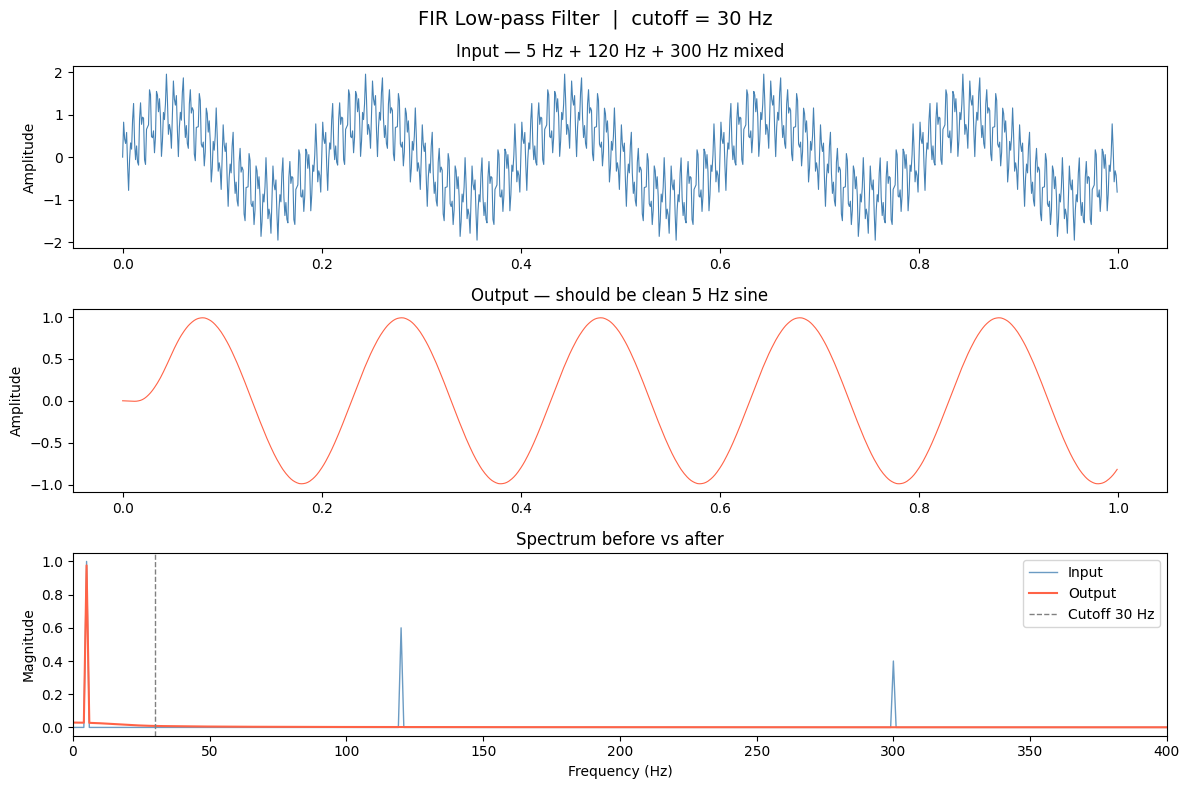

In [ ]:
import numpy as np
from scipy.signal import firwin
import matplotlib.pyplot as plt

# 1000 Hz ADC, must match the real hardware otherwise everything shift
fs = 1000
N  = 1000        # 1 second of data
t  = np.linspace(0, N/fs, N, endpoint=False)

# 5 Hz is our actual signal, the rest is just noise (motor, EMI, whatever)
f_low  = 5
f_mid  = 120
f_high = 300

# what the ADC sees in real world — useful signal buried in noise
signal = (1.0 * np.sin(2 * np.pi * f_low  * t) +
          0.6 * np.sin(2 * np.pi * f_mid  * t) +
          0.4 * np.sin(2 * np.pi * f_high * t))

# 30 Hz gives good margin between what we keep (5Hz) and what we kill (120Hz+)
cutoff = 30

# 61 is good tradeoff, odd number to avoid half-sample delay issues
# tune this down if MCU cycles are tight
num_taps = 61

# firwin compute the coefficients for us, hamming is safe default choice
coeffs = firwin(num_taps, cutoff, fs=fs, window='hamming')

# same math a DSP library do, just not optimized
filtered = fir_filter(list(signal), list(coeffs))

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle('FIR Low-pass Filter  |  cutoff = 30 Hz', fontsize=14)

axes[0].plot(t, signal, color='steelblue', linewidth=0.8)
axes[0].set_title('Input — 5 Hz + 120 Hz + 300 Hz mixed')
axes[0].set_ylabel('Amplitude')

# first ~30 samples will have transient, thats normal, filter need time to fill up
axes[1].plot(t, filtered, color='tomato', linewidth=0.8)
axes[1].set_title('Output — should be clean 5 Hz sine')
axes[1].set_ylabel('Amplitude')

# rfft give us positive freqs only, enough to see the spikes
freqs  = np.fft.rfftfreq(N, 1/fs)
sp_in  = np.abs(np.fft.rfft(signal))   / (N/2)
sp_out = np.abs(np.fft.rfft(filtered)) / (N/2)

# blue has 3 spikes, red should have only one at 5 Hz
axes[2].plot(freqs, sp_in,  color='steelblue', linewidth=1,   label='Input',  alpha=0.8)
axes[2].plot(freqs, sp_out, color='tomato',    linewidth=1.5, label='Output')
axes[2].axvline(cutoff, color='gray', linestyle='--', linewidth=1, label=f'Cutoff {cutoff} Hz')
axes[2].set_xlim(0, 400)
axes[2].set_title('Spectrum before vs after')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Magnitude')
axes[2].legend()

plt.tight_layout()
plt.savefig('fir_output.png', dpi=150)
plt.show()